# MentalChat16K — Linguistic Feature Analysis
**Revised Aim:** Can linguistic features distinguish real from synthetic mental health counselling responses, and do the differences reflect meaningful gaps in therapeutic quality?

Base code: Prof Tan | Extended by: Raymond

## 0. Install Dependencies (run once)

In [2]:
import pandas as pd
print(pd.__version__)

3.0.2


In [3]:
import sys
print(sys.version)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [4]:
import sys
print(sys.executable)

c:\Users\Aung Yee Mon Myo\AppData\Local\Programs\Python\Python314\python.exe


In [5]:
%pip install textblob textstat pandas seaborn matplotlib scipy numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [6]:
import pandas as pd
import numpy as np
import textstat
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import re
import warnings
warnings.filterwarnings('ignore')

# Classifier imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)

print('All imports successful!')

All imports successful!


## 2. Load Dataset

In [7]:
df = pd.read_csv('mentalchat16k_full_features.csv', encoding='utf-8')
print(f'Dataset shape: {df.shape}')
print(f'Sources: {df["source"].value_counts().to_dict()}')
df.head()

Dataset shape: (16081, 25)
Sources: {'synthetic': 9774, 'real': 6307}


,input,output,source,flesch_reading_ease,gunning_fog,smog,dale_chall,polarity,subjectivity,negation_count,...,avg_chars_per_word,unique_word_count,type_token_ratio,hedge_count,hedge_ratio,first_person_count,second_person_count,third_person_count,question_mark_count,ellipsis_count
0,I've been struggling with my mental health for...,I understand that you've been dealing with a s...,real,47.929470,15.174105,14.314029,10.117593,0.062016,0.429209,1.0,...,5.165289,147.0,0.607438,3.0,0.012397,2.0,11.0,8.0,0.0,0.0
1,I've been feeling overwhelmed with my caregivi...,"Your situation is complex, and it's important ...",real,20.940000,19.523810,16.785176,11.197536,0.172917,0.641667,0.0,...,5.816667,82.0,0.683333,2.0,0.016667,3.0,9.0,3.0,0.0,0.0
2,I've been feeling constantly anxious and unabl...,I can see that you're dealing with a great dea...,real,46.965626,14.151650,13.861481,9.764565,0.238690,0.512543,1.0,...,5.053292,158.0,0.495298,10.0,0.031348,2.0,18.0,9.0,0.0,0.0
3,"My mom has Alzheimer's, and I've been her prim...",I'm sorry to hear that your siblings' demands ...,real,35.493636,16.981818,15.903189,10.648950,-0.100000,0.513542,2.0,...,5.352273,65.0,0.738636,2.0,0.022727,0.0,7.0,4.0,0.0,0.0
4,"I've tried setting boundaries, but it feels li...","Your concerns are valid, and it's crucial to p...",real,29.603250,17.680000,16.156166,11.825903,0.166667,0.544444,0.0,...,5.718750,77.0,0.802083,2.0,0.020833,0.0,6.0,2.0,0.0,0.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16081 entries, 0 to 16080
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   input                   16054 non-null  str    
 1   output                  16081 non-null  str    
 2   source                  16081 non-null  str    
 3   flesch_reading_ease     16081 non-null  float64
 4   gunning_fog             16081 non-null  float64
 5   smog                    16081 non-null  float64
 6   dale_chall              16081 non-null  float64
 7   polarity                16081 non-null  float64
 8   subjectivity            16081 non-null  float64
 9   negation_count          16081 non-null  float64
 10  has_negation            16081 non-null  float64
 11  word_count              16081 non-null  float64
 12  sentence_count          16081 non-null  float64
 13  char_count              16081 non-null  float64
 14  avg_words_per_sentence  16081 non-null  float64
 

## 3. Extended Linguistic Feature Extraction

### Features computed:
**Readability:** Flesch Reading Ease, Gunning Fog, SMOG, Dale-Chall  
**Sentiment/Subjectivity:** Polarity, Subjectivity  
**Negation:** Negation count, Has negation  
**Length & Structure:** Word count, Sentence count, Char count, Avg words/sentence, Avg chars/word  
**Lexical Diversity:** Unique word count, Type-Token Ratio (TTR)  
**Confidence/Hedging:** Hedge word count, Hedge ratio  
**Point of View:** 1st person count, 2nd person count, 3rd person count  
**Punctuation:** Question mark count, Ellipsis count

In [9]:
NEGATION_WORDS = {'not', 'no', 'never', 'none', "n't", 'cannot'}

HEDGE_WORDS = {
    'perhaps', 'maybe', 'might', 'could', 'somewhat', 'probably', 'likely',
    'possibly', 'seems', 'appear', 'appears', 'suggest', 'suggests',
    'indicate', 'indicates', 'tend', 'tends', 'generally', 'usually',
    'often', 'sometimes', 'may', 'can', 'around', 'approximately',
    'roughly', 'fairly', 'rather', 'quite', 'somewhat', 'sort', 'kind',
    'type', 'certain', 'uncertain'
}

FIRST_PERSON  = {'i', 'me', 'my', 'mine', 'myself', 'we', 'us', 'our', 'ours', 'ourselves'}
SECOND_PERSON = {'you', 'your', 'yours', 'yourself', 'yourselves'}
THIRD_PERSON  = {'he', 'she', 'they', 'him', 'her', 'them', 'his', 'hers',
                 'their', 'theirs', 'himself', 'herself', 'themselves', 'it', 'its'}


def compute_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}

    features = {}

    # Readability
    features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
    features['gunning_fog']         = textstat.gunning_fog(text)
    features['smog']                = textstat.smog_index(text)
    features['dale_chall']          = textstat.dale_chall_readability_score(text)

    # Sentiment
    blob = TextBlob(text)
    features['polarity']     = blob.sentiment.polarity
    features['subjectivity'] = blob.sentiment.subjectivity

    # Tokenise
    tokens = text.lower().split()
    word_tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
    word_tokens = [t for t in word_tokens if t]

    # Negation
    features['negation_count'] = sum(t in NEGATION_WORDS for t in tokens)
    features['has_negation']   = int(features['negation_count'] > 0)

    # Length & Structure
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    features['word_count']             = len(word_tokens)
    features['sentence_count']         = max(len(sentences), 1)
    features['char_count']             = len(text)
    features['avg_words_per_sentence'] = len(word_tokens) / max(len(sentences), 1)
    features['avg_chars_per_word']     = (sum(len(w) for w in word_tokens) /
                                          max(len(word_tokens), 1))

    # Lexical Diversity
    features['unique_word_count'] = len(set(word_tokens))
    features['type_token_ratio']  = len(set(word_tokens)) / max(len(word_tokens), 1)

    # Hedging
    hedge_count = sum(t in HEDGE_WORDS for t in word_tokens)
    features['hedge_count'] = hedge_count
    features['hedge_ratio'] = hedge_count / max(len(word_tokens), 1)

    # Point of View
    features['first_person_count']  = sum(t in FIRST_PERSON  for t in word_tokens)
    features['second_person_count'] = sum(t in SECOND_PERSON for t in word_tokens)
    features['third_person_count']  = sum(t in THIRD_PERSON  for t in word_tokens)

    # Punctuation
    features['question_mark_count'] = text.count('?')
    features['ellipsis_count']      = text.count('...')

    return features

print('Feature extraction function defined.')

Feature extraction function defined.


In [10]:
# Sanity check on one row
sample = df['output'].iloc[0]
compute_features(sample)

{'flesch_reading_ease': 47.929469696969704,
 'gunning_fog': 15.174104683195594,
 'smog': 14.314028922438442,
 'dale_chall': 10.11759311294766,
 'polarity': 0.062015993265993254,
 'subjectivity': 0.4292087542087542,
 'negation_count': 1,
 'has_negation': 1,
 'word_count': 242,
 'sentence_count': 12,
 'char_count': 1536,
 'avg_words_per_sentence': 20.166666666666668,
 'avg_chars_per_word': 5.1652892561983474,
 'unique_word_count': 147,
 'type_token_ratio': 0.6074380165289256,
 'hedge_count': 3,
 'hedge_ratio': 0.012396694214876033,
 'first_person_count': 2,
 'second_person_count': 11,
 'third_person_count': 8,
 'question_mark_count': 0,
 'ellipsis_count': 0}

## 4. Apply Features to Full Dataset

In [11]:
print('Computing features... (this may take a minute)')
features_df = df['output'].apply(lambda x: compute_features(x)).apply(pd.Series)
df_full = pd.concat([df[['input', 'output', 'source']], features_df], axis=1)
print(f'Done. Shape: {df_full.shape}')
df_full.head()

Computing features... (this may take a minute)
Done. Shape: (16081, 25)


,input,output,source,flesch_reading_ease,gunning_fog,smog,dale_chall,polarity,subjectivity,negation_count,...,avg_chars_per_word,unique_word_count,type_token_ratio,hedge_count,hedge_ratio,first_person_count,second_person_count,third_person_count,question_mark_count,ellipsis_count
0,I've been struggling with my mental health for...,I understand that you've been dealing with a s...,real,47.929470,15.174105,14.314029,10.117593,0.062016,0.429209,1.0,...,5.165289,147.0,0.607438,3.0,0.012397,2.0,11.0,8.0,0.0,0.0
1,I've been feeling overwhelmed with my caregivi...,"Your situation is complex, and it's important ...",real,20.940000,19.523810,16.785176,11.197536,0.172917,0.641667,0.0,...,5.816667,82.0,0.683333,2.0,0.016667,3.0,9.0,3.0,0.0,0.0
2,I've been feeling constantly anxious and unabl...,I can see that you're dealing with a great dea...,real,46.965626,14.151650,13.861481,9.764565,0.238690,0.512543,1.0,...,5.053292,158.0,0.495298,10.0,0.031348,2.0,18.0,9.0,0.0,0.0
3,"My mom has Alzheimer's, and I've been her prim...",I'm sorry to hear that your siblings' demands ...,real,35.493636,16.981818,15.903189,10.648950,-0.100000,0.513542,2.0,...,5.352273,65.0,0.738636,2.0,0.022727,0.0,7.0,4.0,0.0,0.0
4,"I've tried setting boundaries, but it feels li...","Your concerns are valid, and it's crucial to p...",real,29.603250,17.680000,16.156166,11.825903,0.166667,0.544444,0.0,...,5.718750,77.0,0.802083,2.0,0.020833,0.0,6.0,2.0,0.0,0.0


In [12]:
n_before = len(df_full)
df_full = df_full[df_full['flesch_reading_ease'] >= 0].reset_index(drop=True)
n_after = len(df_full)
 
print(f"Excluded {n_before - n_after} rows with anomalous (negative) Flesch Reading Ease scores.")
print(f"Dataset size: {n_before} -> {n_after}")
 
# From this point on, every cell that references df_full (Cohen's d / t-test table,
# kurtosis, boxplots, histograms, classifier training) will automatically use the
# cleaned dataset -- no need to re-filter in each individual cell.
 

Excluded 0 rows with anomalous (negative) Flesch Reading Ease scores.
Dataset size: 16081 -> 16081


In [13]:
df_full.describe().round(3)

,flesch_reading_ease,gunning_fog,smog,dale_chall,polarity,subjectivity,negation_count,has_negation,word_count,sentence_count,...,avg_chars_per_word,unique_word_count,type_token_ratio,hedge_count,hedge_ratio,first_person_count,second_person_count,third_person_count,question_mark_count,ellipsis_count
count,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,...,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000,16081.000
mean,39.120,15.549,14.724,10.627,0.153,0.527,0.876,0.577,312.214,18.248,...,5.410,182.396,0.605,9.943,0.031,2.135,18.261,7.390,0.128,0.007
std,8.708,1.945,1.337,0.803,0.074,0.077,0.978,0.494,123.446,8.221,...,0.287,60.054,0.075,5.045,0.011,2.847,8.781,4.638,0.494,0.114
min,2.145,5.969,8.076,5.800,-0.321,0.000,0.000,0.000,33.000,2.000,...,3.894,31.000,0.085,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,33.268,14.222,13.786,10.120,0.110,0.476,0.000,0.000,252.000,13.000,...,5.231,144.000,0.568,6.000,0.024,0.000,13.000,5.000,0.000,0.000
50%,39.132,15.478,14.656,10.672,0.153,0.522,1.000,1.000,329.000,18.000,...,5.421,198.000,0.602,10.000,0.032,1.000,18.000,7.000,0.000,0.000
75%,44.753,16.832,15.605,11.177,0.197,0.572,1.000,1.000,381.000,24.000,...,5.604,224.000,0.639,14.000,0.039,3.000,24.000,9.000,0.000,0.000
max,87.890,24.247,21.194,14.601,0.767,1.000,10.000,1.000,1864.000,89.000,...,6.717,552.000,0.975,56.000,0.090,55.000,134.000,58.000,11.000,3.000


## 5. Split Real vs Synthetic

In [14]:
real_df      = df_full[df_full['source'] == 'real']
synthetic_df = df_full[df_full['source'] == 'synthetic']
print(f'Real responses:      {len(real_df)}')
print(f'Synthetic responses: {len(synthetic_df)}')

Real responses:      6307
Synthetic responses: 9774


## 6. Statistical Analysis — Welch's t-test + Cohen's d

Tests whether each feature differs significantly between real and synthetic responses.  
**Cohen's d** effect size: small = 0.2, medium = 0.5, large = 0.8

In [15]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.var(a, ddof=1) +
                          (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std != 0 else 0


FEATURES = [
    'flesch_reading_ease', 'gunning_fog', 'smog', 'dale_chall',
    'polarity', 'subjectivity',
    'negation_count',
    'word_count', 'sentence_count', 'avg_words_per_sentence', 'avg_chars_per_word',
    'type_token_ratio',
    'hedge_count', 'hedge_ratio',
    'first_person_count', 'second_person_count', 'third_person_count',
    'question_mark_count', 'ellipsis_count'
]

results = []
for feat in FEATURES:
    r = real_df[feat].dropna()
    s = synthetic_df[feat].dropna()
    stat, p = ttest_ind(r, s, equal_var=False)
    d = cohens_d(r.values, s.values)
    results.append({
        'Feature': feat,
        'Mean (Real)': round(r.mean(), 4),
        'Mean (Synthetic)': round(s.mean(), 4),
        't-stat': round(stat, 4),
        'p-value': round(p, 6),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No',
        "Cohen's d": round(d, 4)
    })

results_df = pd.DataFrame(results)
results_df

,Feature,Mean (Real),Mean (Synthetic),t-stat,p-value,Significant (p<0.05),Cohen's d
0,flesch_reading_ease,40.0947,38.4906,10.9791,0.000,Yes,0.1850
1,gunning_fog,15.9755,15.2732,21.4554,0.000,Yes,0.3668
2,smog,15.1243,14.4651,29.6863,0.000,Yes,0.5078
3,dale_chall,10.3140,10.8296,-40.4611,0.000,Yes,-0.6759
4,polarity,0.1402,0.1610,-15.9965,0.000,Yes,-0.2822
5,subjectivity,0.5558,0.5085,36.9671,0.000,Yes,0.6467
6,negation_count,0.9463,0.8312,6.9620,0.000,Yes,0.1179
7,word_count,235.5738,361.6680,-62.2611,0.000,Yes,-1.1784
8,sentence_count,11.5797,22.5518,-102.6028,0.000,Yes,-1.7595
9,avg_words_per_sentence,20.3379,16.5290,77.5365,0.000,Yes,1.2908


## Cohen's d per feature

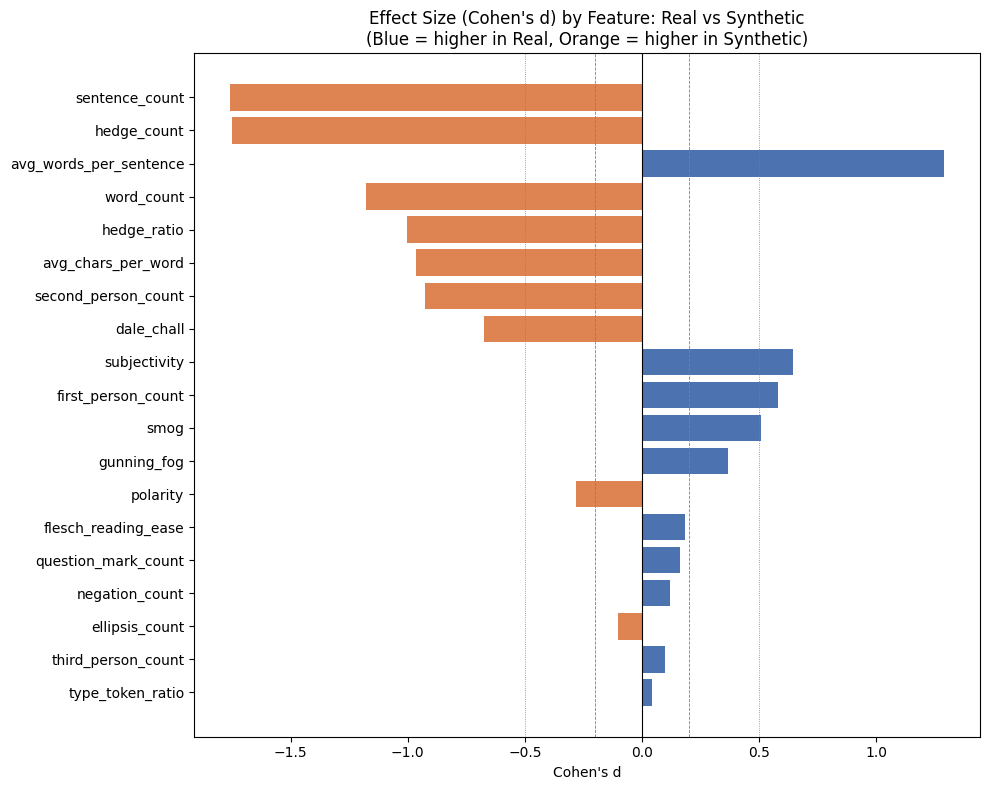

In [16]:
plot_df = results_df.sort_values("Cohen's d", key=abs, ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#4C72B0' if d > 0 else '#DD8452' for d in plot_df["Cohen's d"]]
plt.barh(plot_df['Feature'], plot_df["Cohen's d"], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(0.2, color='gray', linewidth=0.6, linestyle='--')   # small
plt.axvline(-0.2, color='gray', linewidth=0.6, linestyle='--')
plt.axvline(0.5, color='gray', linewidth=0.6, linestyle=':')    # medium
plt.axvline(-0.5, color='gray', linewidth=0.6, linestyle=':')
plt.title("Effect Size (Cohen's d) by Feature: Real vs Synthetic\n(Blue = higher in Real, Orange = higher in Synthetic)")
plt.xlabel("Cohen's d")
plt.tight_layout()
plt.savefig('cohens_d_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualizations
### 7a. Boxplots — Key Features

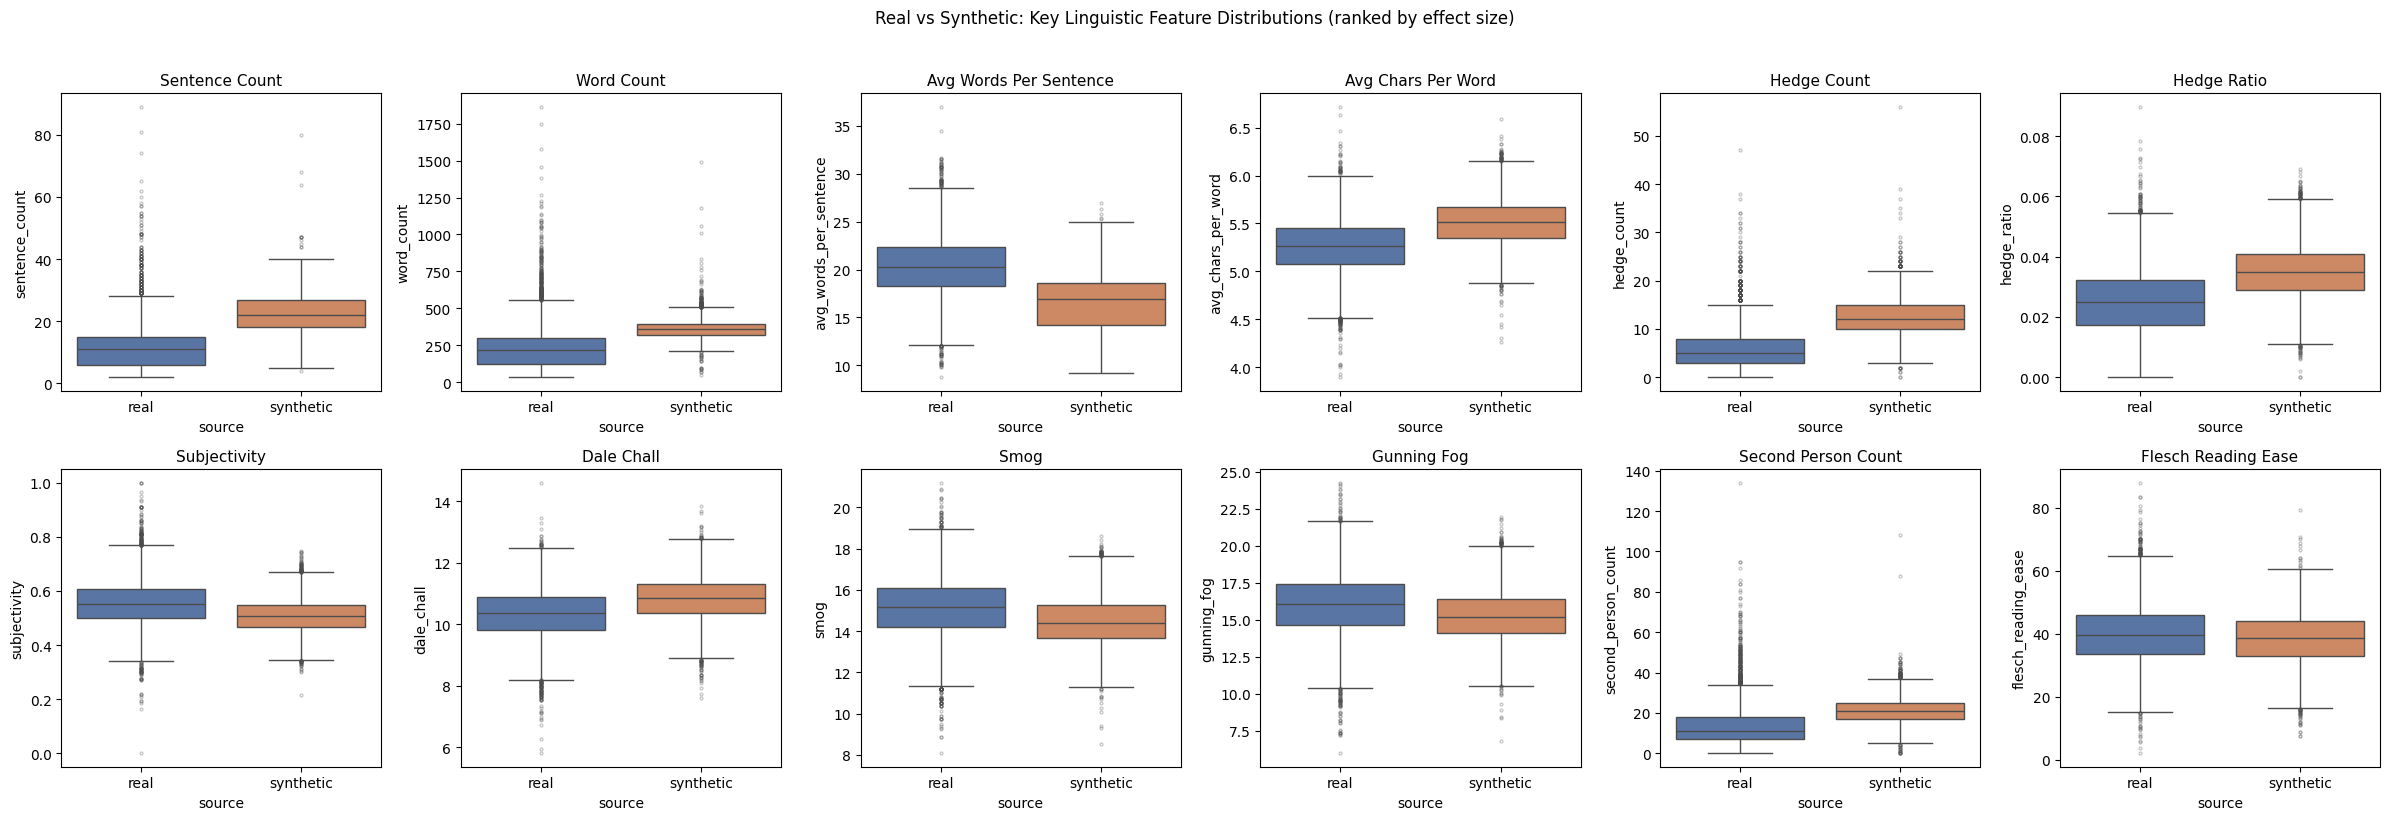

In [17]:
PLOT_FEATURES = [
    'sentence_count', 'word_count', 'avg_words_per_sentence', 'avg_chars_per_word',
    'hedge_count', 'hedge_ratio',
    'subjectivity', 'dale_chall',
    'smog', 'gunning_fog',
    'second_person_count', 'flesch_reading_ease'
]
# Swapped out type_token_ratio and polarity (both negligible effect sizes, d < 0.1)
# and added sentence_count, hedge_count, avg_chars_per_word, second_person_count --
# your actual top discriminating features by Cohen's d.

df_plot = df_full[df_full['flesch_reading_ease'] >= 0].copy()
palette = {'real': '#4C72B0', 'synthetic': '#DD8452'}

fig, axes = plt.subplots(2, 6, figsize=(24, 8))
axes = axes.flatten()

for i, feat in enumerate(PLOT_FEATURES):
    sns.boxplot(
        x='source', y=feat, data=df_plot,
        palette=palette, ax=axes[i],
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11)

plt.suptitle('Real vs Synthetic: Key Linguistic Feature Distributions (ranked by effect size)', y=1.02)
plt.tight_layout()
plt.savefig('boxplots_key_features_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b. Histograms with KDE — Sentiment Features

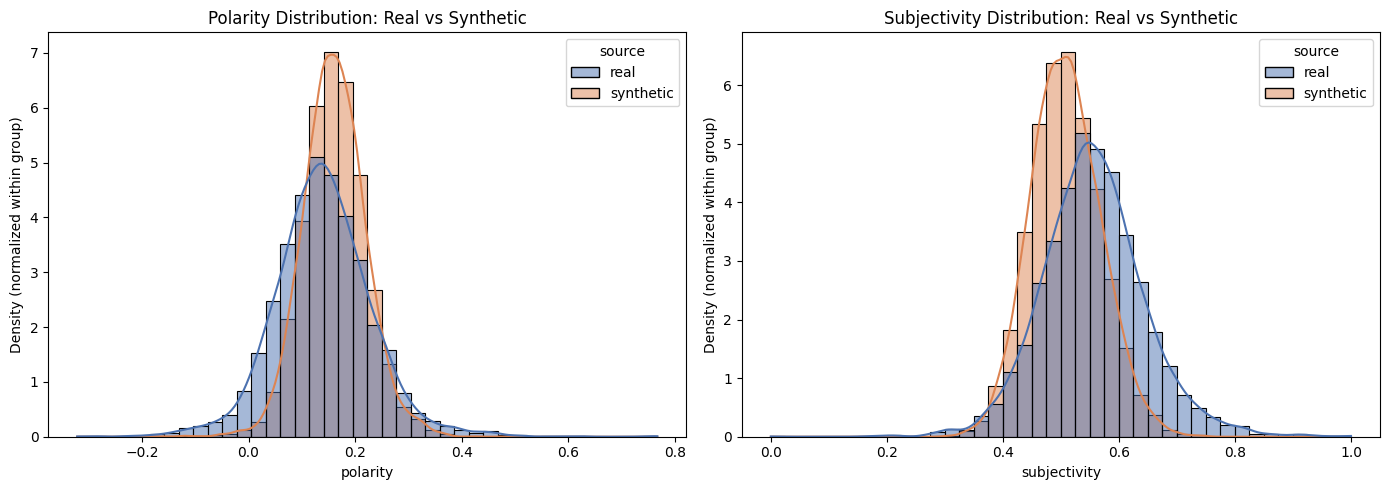

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['polarity', 'subjectivity']):
    sns.histplot(
        data=df_full, x=feat, hue='source',
        kde=True, bins=40, alpha=0.5,
        stat='density',      # normalize y-axis to density instead of raw count
        common_norm=False,   # normalize each group (real/synthetic) to its own total,
                              # so the ~9774 vs ~6310 sample-size gap doesn't distort the shapes
        palette=palette, ax=ax
    )
    ax.set_ylabel('Density (normalized within group)')
    ax.set_title(f'{feat.title()} Distribution: Real vs Synthetic', fontsize=12)

plt.tight_layout()
plt.savefig('histograms_sentiment_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

### 7c. Normalised Mean Feature Bar Chart (Bug so Scrapped)

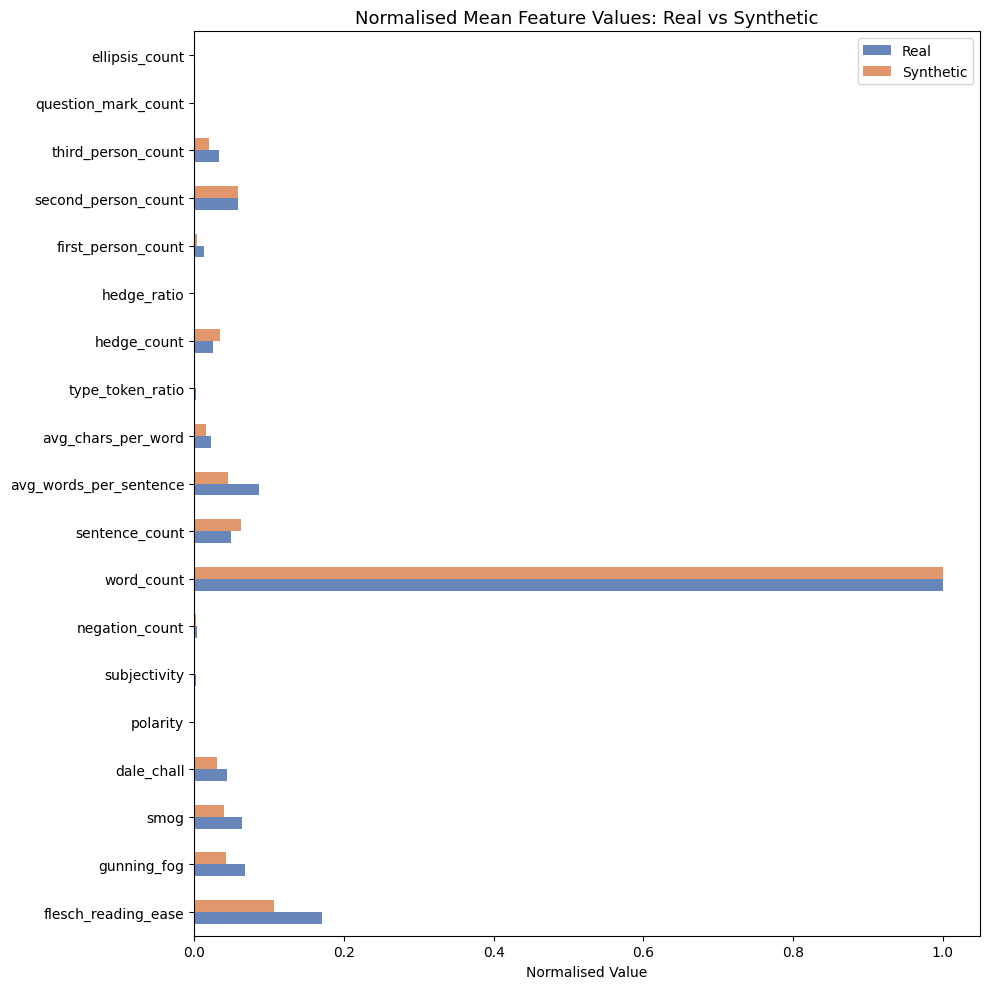

In [19]:
mean_by_source = df_full.groupby('source')[FEATURES].mean().T
mean_by_source.columns = ['Real', 'Synthetic']

norm = mean_by_source.copy()
for col in norm.columns:
    rng = norm[col].max() - norm[col].min()
    if rng != 0:
        norm[col] = (norm[col] - norm[col].min()) / rng

norm.plot(kind='barh', figsize=(10, 10), color=['#4C72B0', '#DD8452'], alpha=0.85)
plt.title('Normalised Mean Feature Values: Real vs Synthetic', fontsize=13)
plt.xlabel('Normalised Value')
plt.tight_layout()
plt.savefig('barchart_mean_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 7d. Point-of-View Pronoun Comparison

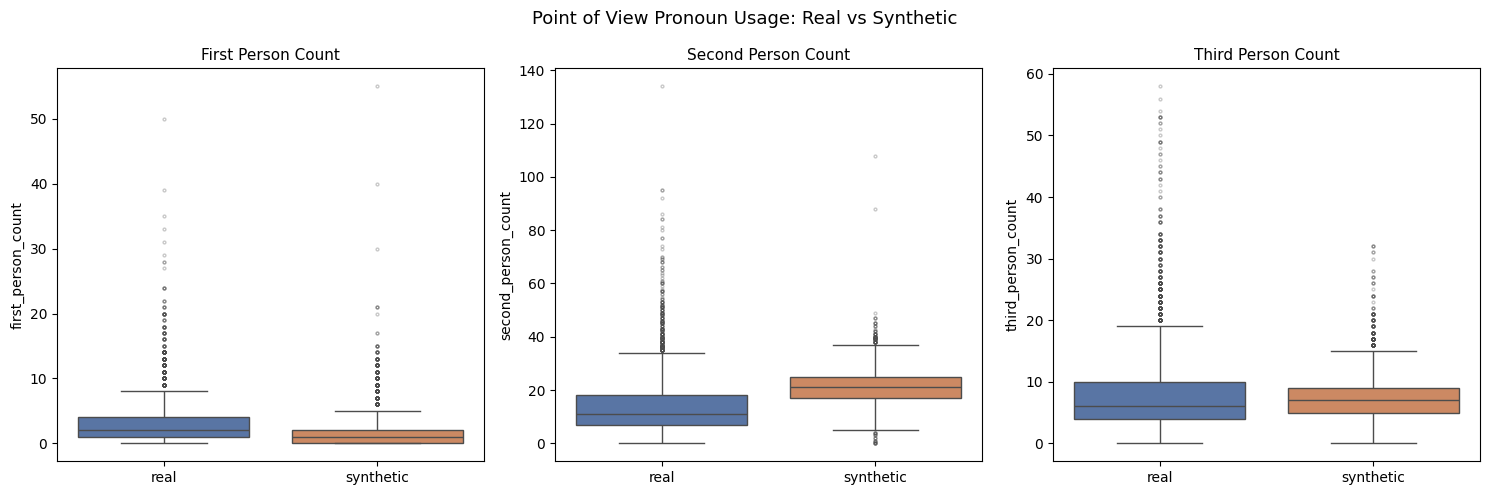

In [20]:
pov_features = ['first_person_count', 'second_person_count', 'third_person_count']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, pov_features):
    sns.boxplot(x='source', y=feat, data=df_full, palette=palette, ax=ax,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Point of View Pronoun Usage: Real vs Synthetic', fontsize=13)
plt.tight_layout()
plt.savefig('pov_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Investigation — Negative Flesch Reading Ease

In [21]:
neg_flesch = df_full[df_full['flesch_reading_ease'] < 0][
    ['output', 'source', 'flesch_reading_ease', 'word_count', 'avg_words_per_sentence']
]
print(f'Rows with negative Flesch score: {len(neg_flesch)}')
neg_flesch.head(5)

Rows with negative Flesch score: 0


,output,source,flesch_reading_ease,word_count,avg_words_per_sentence


## 9. Save Full Dataset with All Features

In [22]:
df_full.to_csv('mentalchat16k_full_features.csv', index=False, encoding='utf-8')
print('Saved to mentalchat16k_full_features.csv')

Saved to mentalchat16k_full_features.csv


## 10. Classifier — Can Linguistic Features Predict Real vs Synthetic? (RQ3)

We train two simple models:
- **Logistic Regression** — interpretable, good baseline
- **Decision Tree** — shows feature importance visually

We use an 80/20 train-test split and report accuracy, precision, recall, and F1.

In [23]:
# Prepare features and labels
X = df_full[FEATURES].fillna(0)
y = (df_full['source'] == 'real').astype(int)  # 1 = real, 0 = synthetic

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

Training samples: 12864
Test samples:     3217


### 10a. Logistic Regression

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Synthetic', 'Real']))

=== Logistic Regression ===
              precision    recall  f1-score   support

   Synthetic       0.97      0.97      0.97      1955
        Real       0.96      0.96      0.96      1262

    accuracy                           0.97      3217
   macro avg       0.97      0.97      0.97      3217
weighted avg       0.97      0.97      0.97      3217



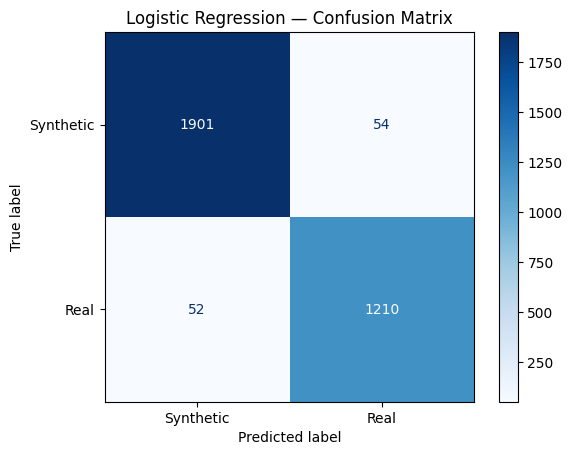

In [25]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Synthetic', 'Real'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 10a.1 Confusion matrix — investigating the 54 and 55 misclassifications

In [26]:
# y_test and y_pred_lr are already indexed to match X_test's original rows
mistakes = X_test.copy()
mistakes['true_source']  = y_test.map({1: 'real', 0: 'synthetic'})
mistakes['pred_source']  = pd.Series(y_pred_lr, index=X_test.index).map({1: 'real', 0: 'synthetic'})
mistakes['output_text']  = df_full.loc[X_test.index, 'output']

false_real  = mistakes[(mistakes['true_source'] == 'synthetic') & (mistakes['pred_source'] == 'real')]
false_synth = mistakes[(mistakes['true_source'] == 'real')      & (mistakes['pred_source'] == 'synthetic')]

print(f"False Real (synthetic mistaken for real): {len(false_real)} rows")
print(f"False Synthetic (real mistaken for synthetic): {len(false_synth)} rows\n")

print("--- Sample: synthetic responses that 'passed' as real ---")
for txt in false_real['output_text'].head(3):
    print('-', txt[:150].replace('\n',' '), '...\n')

print("--- Sample: real responses mistaken for synthetic ---")
for txt in false_synth['output_text'].head(3):
    print('-', txt[:150].replace('\n',' '), '...\n')

# Quantitative check: do the mistakes cluster around your top discriminating features?
print("\nMean sentence_count -- correct vs mistaken:")
print("  Correctly classified real:", mistakes[(mistakes.true_source=='real') & (mistakes.pred_source=='real')]['sentence_count'].mean())
print("  Real misclassified as synthetic:", false_synth['sentence_count'].mean())
print("  Correctly classified synthetic:", mistakes[(mistakes.true_source=='synthetic') & (mistakes.pred_source=='synthetic')]['sentence_count'].mean())
print("  Synthetic misclassified as real:", false_real['sentence_count'].mean())

False Real (synthetic mistaken for real): 54 rows
False Synthetic (real mistaken for synthetic): 52 rows

--- Sample: synthetic responses that 'passed' as real ---
- I can understand how challenging it must be for you to navigate intimacy in your relationship. It takes a lot of courage to open up about these feelin ...

- Navigating an ethical dilemma in the workplace can indeed be challenging and create a sense of conflict within ourselves. It's important to remember t ...

- I completely understand your concerns about going to counseling for the first time. It's natural to feel hesitant about opening up to someone you don' ...

--- Sample: real responses mistaken for synthetic ---
- I can see how deeply you value the opportunity to work with children and how much you've invested in the idea of a career in education. It's understan ...

- Your concerns are valid, and it's natural to feel apprehensive about sharing your mental health struggles with your children. However, it's essentia

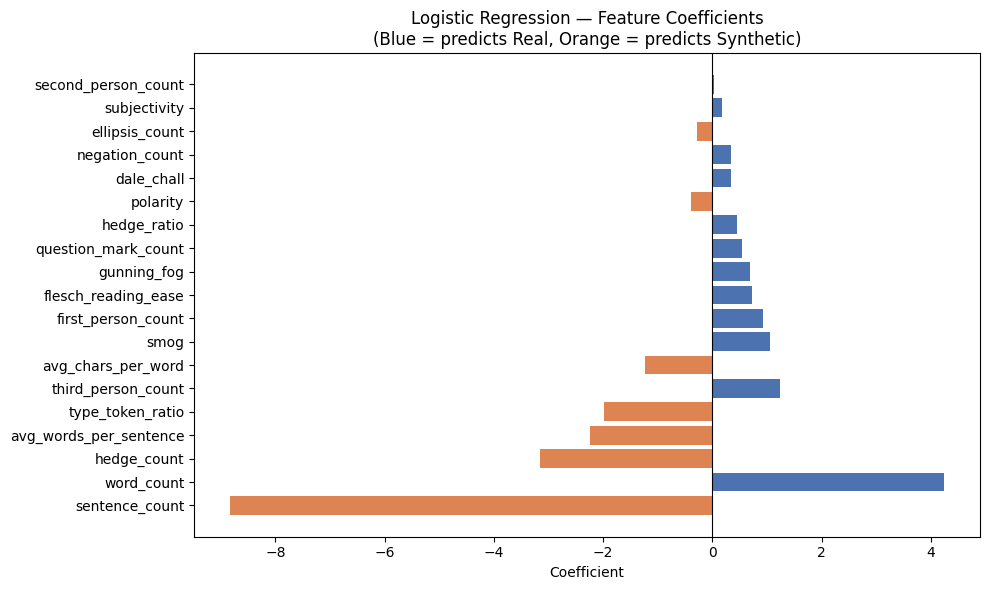

In [27]:
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#4C72B0' if c > 0 else '#DD8452' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients\n(Blue = predicts Real, Orange = predicts Synthetic)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('lr_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

### 10a.2 P-values for coefficients

In [28]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(pd.DataFrame(X_train_scaled, columns=FEATURES))
logit_model = sm.Logit(y_train.reset_index(drop=True), X_train_sm).fit()
print(logit_model.summary())
# The P>|z| column gives you a real significance test per coefficient --
# use this table instead of/alongside the sklearn coefficient chart if your
# mentor wants formal significance claims, not just relative magnitude.

         Current function value: 0.100026
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 source   No. Observations:                12864
Model:                          Logit   Df Residuals:                    12844
Method:                           MLE   Df Model:                           19
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                  0.8506
Time:                        12:54:20   Log-Likelihood:                -1286.7
converged:                      False   LL-Null:                       -8615.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.8992     19.276     -0.150      0.880     -40.679      34.881
flesch_reading_ease        0.

c:\Users\Aung Yee Mon Myo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 10b. Decision Tree

In [29]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Synthetic', 'Real']))

=== Decision Tree ===
              precision    recall  f1-score   support

   Synthetic       0.97      0.97      0.97      1955
        Real       0.95      0.95      0.95      1262

    accuracy                           0.96      3217
   macro avg       0.96      0.96      0.96      3217
weighted avg       0.96      0.96      0.96      3217



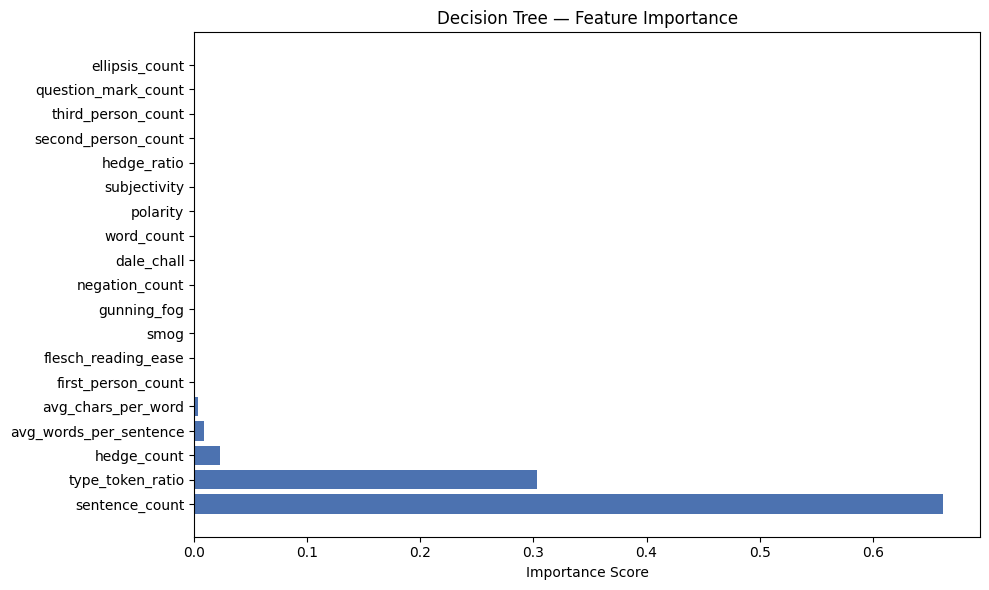

In [30]:
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#4C72B0')
plt.title('Decision Tree — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

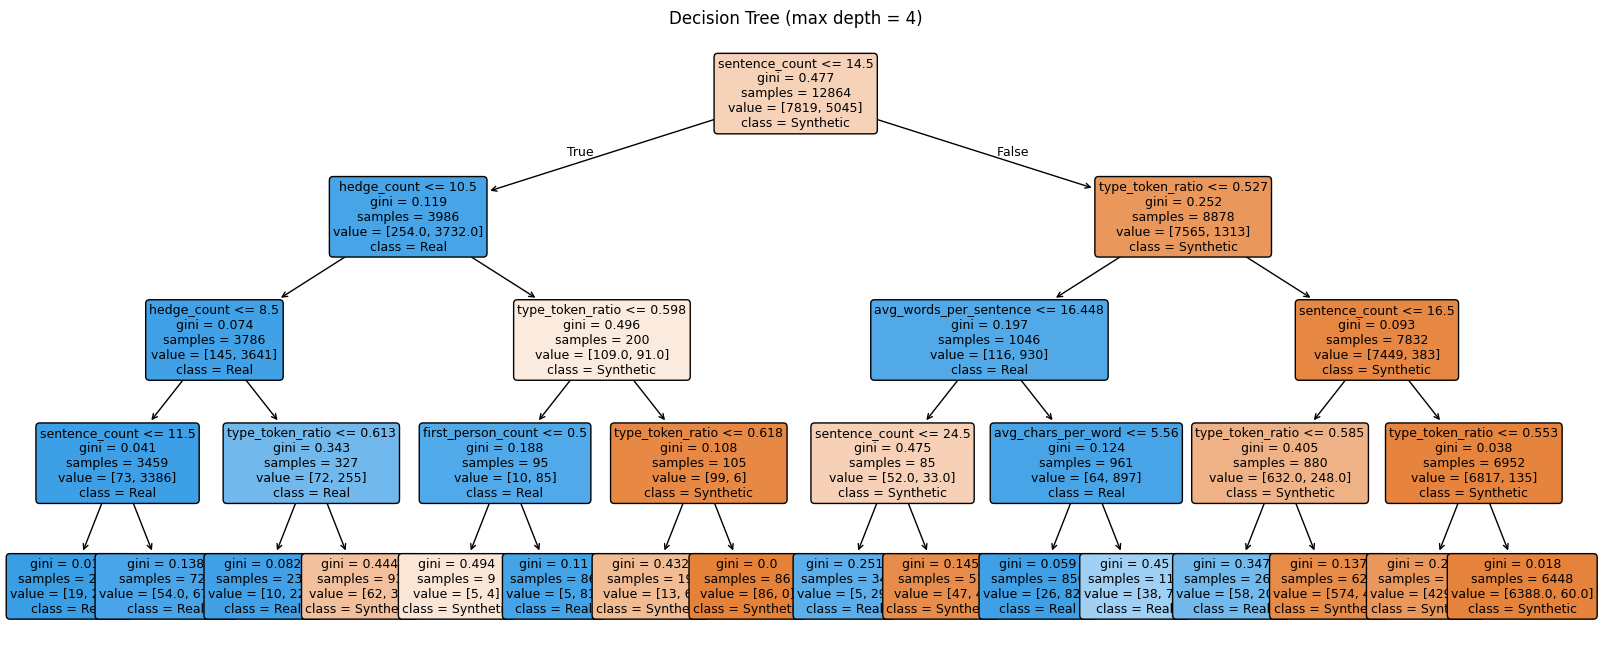

In [31]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt, feature_names=FEATURES,
    class_names=['Synthetic', 'Real'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree (max depth = 4)')
plt.savefig('decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 10c. Model Comparison Summary

In [32]:
summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': round(accuracy_score(y_test, y_pred_lr), 4),
        'F1 (Real)': round(f1_score(y_test, y_pred_lr), 4),
        'F1 (Synthetic)': round(f1_score(y_test, y_pred_lr, pos_label=0), 4)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': round(accuracy_score(y_test, y_pred_dt), 4),
        'F1 (Real)': round(f1_score(y_test, y_pred_dt), 4),
        'F1 (Synthetic)': round(f1_score(y_test, y_pred_dt, pos_label=0), 4)
    }
])

print('=== Model Comparison ===')
summary

=== Model Comparison ===


,Model,Accuracy,F1 (Real),F1 (Synthetic)
0,Logistic Regression,0.9671,0.9580,0.9729
1,Decision Tree,0.9621,0.9515,0.9689


## 11. Research Questions

**Revised Aim:** Can linguistic features distinguish real from synthetic mental health counselling responses, and do the differences reflect meaningful gaps in therapeutic quality?

---

**RQ1.** Which linguistic features most significantly distinguish real from synthetic mental health counselling responses?

**RQ2.** Do synthetic responses show systematic patterns (e.g. overly positive sentiment, less lexical diversity, more hedging) that may make them less therapeutically authentic?

**RQ3.** Can a simple model trained on linguistic features reliably classify whether a response is real or synthetic?

## To-DO

PHD Student: Quality & Empahty

Quality: Paid for Human Analyst + Multiple AI ($$$) -> Differnce in Quality was Negligible
Empathy: Medical Analyst to rate empathy + AI Models Rating


For my Project:
Peers Rating Survey w Rewards (smol SB voucher)
Run AI Models